In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [2]:
df = pd.read_csv("data/train_full.csv")

df["image_path"] = df["image_path"].str.replace("\\", "/", regex=False)
df["image_path"] = df["image_path"].str.replace(
    "data/train_data/",
    "data/train_data/train_data/",
    regex=False
)

df.head()

,id,xmin,ymin,xmax,ymax,direction,split,image_path
0,image_0,-228.877144,223.618740,-110.614879,416.358789,1,val,data/train_data/train_data/image_0.png
1,image_2,871.866846,218.142342,945.359631,423.076854,0,train,data/train_data/train_data/image_2.png
2,image_3,-224.589965,220.840143,-146.401974,409.747294,0,val,data/train_data/train_data/image_3.png
3,image_4,898.981190,215.768093,956.279097,429.133944,1,train,data/train_data/train_data/image_4.png
4,image_5,-166.975923,223.755640,-118.486304,369.332377,1,val,data/train_data/train_data/image_5.png


In [3]:
from PIL import Image

def get_image_size(path):
    with Image.open(path) as img:
        return img.size  # (w, h)

sizes = df["image_path"].apply(get_image_size)
df["img_w"] = sizes.apply(lambda x: x[0])
df["img_h"] = sizes.apply(lambda x: x[1])

# original box center and size in pixels
df["cx"] = (df["xmin"] + df["xmax"]) / 2.0
df["cy"] = (df["ymin"] + df["ymax"]) / 2.0
df["bw"] = df["xmax"] - df["xmin"]
df["bh"] = df["ymax"] - df["ymin"]

# normalized center only
df["cx_n"] = df["cx"] / df["img_w"]
df["cy_n"] = df["cy"] / df["img_h"]

# optional clipping to make regression less unstable
df["cx_n"] = df["cx_n"].clip(-0.5, 1.5)
df["cy_n"] = df["cy_n"].clip(-0.5, 1.5)

print(df[["cx_n", "cy_n"]].describe())
print(df["direction"].value_counts())
print(df["split"].value_counts())

              cx_n         cy_n
count  1692.000000  1692.000000
mean      0.477690     0.644443
std       0.735164     0.029736
min      -0.401940     0.595894
25%      -0.243715     0.618708
50%      -0.162558     0.641588
75%       1.210537     0.668755
max       1.351650     0.714528
direction
0    874
1    818
Name: count, dtype: int64
split
train    1353
val       339
Name: count, dtype: int64


In [4]:
def get_side_and_distance(cx_n):
    if cx_n < 0:
        return 0, -cx_n   # left
    elif cx_n > 1:
        return 1, cx_n - 1   # right
    else:
        return None, None

side_dist = df["cx_n"].apply(get_side_and_distance)

df["side"] = side_dist.apply(lambda x: x[0])
df["dist_n"] = side_dist.apply(lambda x: x[1])

# keep only samples that are truly outside
df = df[df["side"].notna()].copy().reset_index(drop=True)

df["side"] = df["side"].astype(int)
df["dist_n"] = df["dist_n"].astype(float)

# optional: clip for stability
df["dist_n"] = df["dist_n"].clip(0.0, 1.5)
df["cy_n"] = df["cy_n"].clip(-0.5, 1.5)

print(df[["cx_n", "cy_n", "side", "dist_n"]].head())
print(df["side"].value_counts())

       cx_n      cy_n  side    dist_n
0 -0.235758  0.666643     0  0.235758
1  1.261963  0.667937     1  0.261963
2 -0.257633  0.656862     0  0.257633
3  1.288375  0.671773     1  0.288375
4 -0.198238  0.617800     0  0.198238
side
0    852
1    840
Name: count, dtype: int64


In [5]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 1353
Val: 339


In [6]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [7]:
class ShadowOutsideDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        target = torch.tensor(
            [row["dist_n"], row["cy_n"]],
            dtype=torch.float32
        )

        side = torch.tensor(int(row["side"]), dtype=torch.long)

        meta = {
            "img_w": torch.tensor(row["img_w"], dtype=torch.float32),
            "img_h": torch.tensor(row["img_h"], dtype=torch.float32),
            "true_cx_n": torch.tensor(row["cx_n"], dtype=torch.float32),
            "true_cy_n": torch.tensor(row["cy_n"], dtype=torch.float32),
            "id": row["id"]
        }

        return img, target, side, meta

In [8]:
class ShadowOutsideModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.geo_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)   # raw distance, raw cy
        )

        self.side_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.backbone(x)

        raw_geo = self.geo_head(features)
        raw_dist = raw_geo[:, 0:1]
        raw_cy = raw_geo[:, 1:2]

        # distance must be >= 0
        dist_n = torch.nn.functional.softplus(raw_dist)

        # cy can be slightly outside image, but keep it bounded
        cy_n = 2.0 * torch.sigmoid(raw_cy) - 0.5   # range [-0.5, 1.5]

        side_logits = self.side_head(features)

        return dist_n, cy_n, side_logits

In [9]:
def reconstruct_cx_from_side_and_dist(side_pred, dist_n):
    """
    side_pred: [B] with 0=left, 1=right
    dist_n: [B, 1] or [B]
    """
    if dist_n.ndim > 1:
        dist_n = dist_n.squeeze(1)

    cx_n = torch.where(
        side_pred == 0,
        -dist_n,
        1.0 + dist_n
    )
    return cx_n

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = ShadowOutsideModel().to(device)

reg_loss_fn = nn.SmoothL1Loss()
cls_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

Device: cpu


In [11]:
def compute_center_error_pixels(pred_center, true_center, img_w, img_h):
    """
    pred_center: [B, 2] normalized
    true_center: [B, 2] normalized
    img_w, img_h: [B]
    """
    pred_x = pred_center[:, 0] * img_w
    pred_y = pred_center[:, 1] * img_h

    true_x = true_center[:, 0] * img_w
    true_y = true_center[:, 1] * img_h

    err = torch.sqrt((pred_x - true_x) ** 2 + (pred_y - true_y) ** 2)
    return err

In [12]:
def train_one_epoch(model, loader, optimizer, reg_loss_fn, cls_loss_fn, device):
    model.train()
    total_loss = 0.0
    total_dist_loss = 0.0
    total_cy_loss = 0.0
    total_side_loss = 0.0

    for images, target, true_side, _ in loader:
        images = images.to(device)
        target = target.to(device)         # [dist_n, cy_n]
        true_side = true_side.to(device)

        true_dist = target[:, 0:1]
        true_cy = target[:, 1:2]

        optimizer.zero_grad()

        pred_dist, pred_cy, pred_side_logits = model(images)

        dist_loss = reg_loss_fn(pred_dist, true_dist)
        cy_loss = reg_loss_fn(pred_cy, true_cy)
        side_loss = cls_loss_fn(pred_side_logits, true_side)

        loss = dist_loss + cy_loss + 1.5 * side_loss
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_dist_loss += dist_loss.item() * batch_size
        total_cy_loss += cy_loss.item() * batch_size
        total_side_loss += side_loss.item() * batch_size

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "dist_loss": total_dist_loss / n,
        "cy_loss": total_cy_loss / n,
        "side_loss": total_side_loss / n
    }

In [13]:
def validate(model, loader, reg_loss_fn, cls_loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_dist_loss = 0.0
    total_cy_loss = 0.0
    total_side_loss = 0.0

    all_side_correct = []
    all_center_errors = []
    all_pred_inside = []

    with torch.no_grad():
        for images, target, true_side, meta in loader:
            images = images.to(device)
            target = target.to(device)
            true_side = true_side.to(device)

            true_dist = target[:, 0:1]
            true_cy = target[:, 1:2]

            pred_dist, pred_cy, pred_side_logits = model(images)

            dist_loss = reg_loss_fn(pred_dist, true_dist)
            cy_loss = reg_loss_fn(pred_cy, true_cy)
            side_loss = cls_loss_fn(pred_side_logits, true_side)

            loss = dist_loss + cy_loss + 1.5 * side_loss

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_dist_loss += dist_loss.item() * batch_size
            total_cy_loss += cy_loss.item() * batch_size
            total_side_loss += side_loss.item() * batch_size

            pred_side = pred_side_logits.argmax(dim=1)
            side_correct = (pred_side == true_side).float()
            all_side_correct.extend(side_correct.cpu().numpy())

            pred_cx_n = reconstruct_cx_from_side_and_dist(pred_side, pred_dist)
            pred_cy_n = pred_cy.squeeze(1)

            true_cx_n = meta["true_cx_n"].to(device)
            true_cy_n = meta["true_cy_n"].to(device)

            img_w = meta["img_w"].to(device)
            img_h = meta["img_h"].to(device)

            pred_x = pred_cx_n * img_w
            pred_y = pred_cy_n * img_h

            true_x = true_cx_n * img_w
            true_y = true_cy_n * img_h

            center_err = torch.sqrt((pred_x - true_x) ** 2 + (pred_y - true_y) ** 2)
            all_center_errors.extend(center_err.cpu().numpy())

            pred_inside = ((pred_cx_n >= 0.0) & (pred_cx_n <= 1.0)).float()
            all_pred_inside.extend(pred_inside.cpu().numpy())

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "dist_loss": total_dist_loss / n,
        "cy_loss": total_cy_loss / n,
        "side_loss": total_side_loss / n,
        "side_acc": float(np.mean(all_side_correct)),
        "center_error_px": float(np.mean(all_center_errors)),
        "pred_inside_rate": float(np.mean(all_pred_inside))
    }

In [14]:
def unfreeze_layer4(model):
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

In [15]:
import copy,math

In [16]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)

train_dataset = ShadowOutsideDataset(train_df, transform=train_transform)
val_dataset = ShadowOutsideDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [17]:
num_epochs = 15
unfreeze_epoch = 6

history = []
best_model_wts = copy.deepcopy(model.state_dict())
best_center_error = float("inf")
best_side_acc = 0.0
best_epoch = -1

for epoch in range(num_epochs):
    if epoch == unfreeze_epoch:
        print("\nUnfreezing backbone layer4...\n")
        unfreeze_layer4(model)

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=5e-5,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2
        )

    train_metrics = train_one_epoch(
        model, train_loader, optimizer, reg_loss_fn, cls_loss_fn, device
    )

    val_metrics = validate(
        model, val_loader, reg_loss_fn, cls_loss_fn, device
    )

    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_dist_loss": train_metrics["dist_loss"],
        "train_cy_loss": train_metrics["cy_loss"],
        "train_side_loss": train_metrics["side_loss"],
        "val_loss": val_metrics["loss"],
        "val_dist_loss": val_metrics["dist_loss"],
        "val_cy_loss": val_metrics["cy_loss"],
        "val_side_loss": val_metrics["side_loss"],
        "val_side_acc": val_metrics["side_acc"],
        "val_center_error_px": val_metrics["center_error_px"],
        "pred_inside_rate": val_metrics["pred_inside_rate"],
        "lr": optimizer.param_groups[0]["lr"]
    }
    history.append(row)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_side_acc={val_metrics['side_acc']:.4f} | "
        f"val_center_error_px={val_metrics['center_error_px']:.2f} | "
        f"pred_inside_rate={val_metrics['pred_inside_rate']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.6f}"
    )

    is_better = False
    if val_metrics["center_error_px"] < best_center_error:
        is_better = True
    elif math.isclose(val_metrics["center_error_px"], best_center_error, rel_tol=1e-6):
        if val_metrics["side_acc"] > best_side_acc:
            is_better = True

    if is_better:
        best_center_error = val_metrics["center_error_px"]
        best_side_acc = val_metrics["side_acc"]
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_shadow_outside_model.pth")

print(f"\nBest epoch: {best_epoch}")
print(f"Best val center error: {best_center_error:.2f}px")
print(f"Best val side acc: {best_side_acc:.4f}")

Epoch 1/15 | train_loss=1.0571 | val_loss=0.9733 | val_side_acc=0.6814 | val_center_error_px=355.36 | pred_inside_rate=0.0000 | lr=0.000100
Epoch 2/15 | train_loss=0.9487 | val_loss=0.9111 | val_side_acc=0.7817 | val_center_error_px=263.14 | pred_inside_rate=0.0000 | lr=0.000100
Epoch 3/15 | train_loss=0.8997 | val_loss=0.8734 | val_side_acc=0.7670 | val_center_error_px=276.82 | pred_inside_rate=0.0000 | lr=0.000100
Epoch 4/15 | train_loss=0.8548 | val_loss=0.8143 | val_side_acc=0.8142 | val_center_error_px=230.99 | pred_inside_rate=0.0000 | lr=0.000100
Epoch 5/15 | train_loss=0.8104 | val_loss=0.7855 | val_side_acc=0.8053 | val_center_error_px=237.89 | pred_inside_rate=0.0000 | lr=0.000100
Epoch 6/15 | train_loss=0.7565 | val_loss=0.7661 | val_side_acc=0.8053 | val_center_error_px=235.82 | pred_inside_rate=0.0000 | lr=0.000100

Unfreezing backbone layer4...

Epoch 7/15 | train_loss=0.3734 | val_loss=0.1306 | val_side_acc=0.9823 | val_center_error_px=56.03 | pred_inside_rate=0.0000 | l

In [18]:
results_df = pd.DataFrame(history)
results_df

,epoch,train_loss,train_dist_loss,train_cy_loss,train_side_loss,val_loss,val_dist_loss,val_cy_loss,val_side_loss,val_side_acc,val_center_error_px,pred_inside_rate,lr
0,1,1.057086,0.017838,0.006916,0.688221,0.973275,0.002020,0.000724,0.647021,0.681416,355.357422,0.0,0.00010
1,2,0.948734,0.002382,0.002741,0.629074,0.911063,0.001723,0.000638,0.605801,0.781711,263.137573,0.0,0.00010
2,3,0.899660,0.002237,0.002151,0.596848,0.873400,0.001746,0.000631,0.580681,0.766962,276.818542,0.0,0.00010
3,4,0.854794,0.002119,0.001733,0.567295,0.814283,0.001677,0.000546,0.541374,0.814159,230.994354,0.0,0.00010
4,5,0.810446,0.002136,0.001512,0.537865,0.785479,0.001727,0.000515,0.522158,0.805310,237.886566,0.0,0.00010
5,6,0.756524,0.002047,0.001317,0.502107,0.766083,0.001638,0.000512,0.509289,0.805310,235.817245,0.0,0.00010
6,7,0.373394,0.002121,0.001132,0.246761,0.130628,0.001605,0.000518,0.085670,0.982301,56.033070,0.0,0.00005
7,8,0.067832,0.002109,0.001125,0.043065,0.059615,0.001570,0.000488,0.038371,0.994100,43.436516,0.0,0.00005
8,9,0.028803,0.001906,0.000948,0.017299,0.047015,0.001489,0.000474,0.030035,0.994100,42.402802,0.0,0.00005
9,10,0.022285,0.002017,0.000931,0.012891,0.033351,0.001427,0.000468,0.020971,0.997050,38.803974,0.0,0.00005


In [20]:
results_df.sort_values(
    ["val_center_error_px", "val_side_acc"],
    ascending=[True, False]
).reset_index(drop=True)

,epoch,train_loss,train_dist_loss,train_cy_loss,train_side_loss,val_loss,val_dist_loss,val_cy_loss,val_side_loss,val_side_acc,val_center_error_px,pred_inside_rate,lr
0,15,0.006529,0.001704,0.000848,0.002651,0.010306,0.001275,0.000433,0.005732,1.000000,33.442848,0.0,0.00005
1,14,0.005459,0.001685,0.000826,0.001965,0.013410,0.001323,0.000468,0.007746,1.000000,34.317028,0.0,0.00005
2,13,0.007923,0.001784,0.000885,0.003503,0.016521,0.001426,0.000463,0.009755,1.000000,35.776657,0.0,0.00005
3,11,0.011303,0.001862,0.000956,0.005657,0.022449,0.001428,0.000459,0.013708,0.997050,38.715828,0.0,0.00005
4,10,0.022285,0.002017,0.000931,0.012891,0.033351,0.001427,0.000468,0.020971,0.997050,38.803974,0.0,0.00005
5,12,0.009431,0.001766,0.000874,0.004528,0.023830,0.001535,0.000488,0.014538,0.997050,40.487160,0.0,0.00005
6,9,0.028803,0.001906,0.000948,0.017299,0.047015,0.001489,0.000474,0.030035,0.994100,42.402802,0.0,0.00005
7,8,0.067832,0.002109,0.001125,0.043065,0.059615,0.001570,0.000488,0.038371,0.994100,43.436516,0.0,0.00005
8,7,0.373394,0.002121,0.001132,0.246761,0.130628,0.001605,0.000518,0.085670,0.982301,56.033070,0.0,0.00005
9,4,0.854794,0.002119,0.001733,0.567295,0.814283,0.001677,0.000546,0.541374,0.814159,230.994354,0.0,0.00010


In [22]:
model.load_state_dict(torch.load("best_shadow_outside_model.pth", map_location=device))
model.eval()

ShadowOutsideModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

inv_normalize = transforms.Normalize(
    mean=[-m / s for m, s in zip(imagenet_mean, imagenet_std)],
    std=[1 / s for s in imagenet_std]
)

def reconstruct_cx_from_side_and_dist(side_pred, dist_n):
    if dist_n.ndim > 1:
        dist_n = dist_n.squeeze(1)

    cx_n = torch.where(
        side_pred == 0,
        -dist_n,
        1.0 + dist_n
    )
    return cx_n

def show_predictions(model, dataset, device, num_samples=6):
    model.eval()

    indices = np.random.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(len(indices), 1, figsize=(8, 4 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img, target, true_side, meta = dataset[idx]

            input_tensor = img.unsqueeze(0).to(device)

            pred_dist, pred_cy, pred_side_logits = model(input_tensor)
            pred_side = pred_side_logits.argmax(dim=1)

            pred_cx_n = reconstruct_cx_from_side_and_dist(pred_side, pred_dist)[0].item()
            pred_cy_n = pred_cy[0, 0].item()
            pred_side_label = int(pred_side.item())

            true_cx_n = meta["true_cx_n"].item()
            true_cy_n = meta["true_cy_n"].item()

            img_w = meta["img_w"].item()
            img_h = meta["img_h"].item()

            true_x = true_cx_n * img_w
            true_y = true_cy_n * img_h

            pred_x = pred_cx_n * img_w
            pred_y = pred_cy_n * img_h

            img_disp = inv_normalize(img).clamp(0, 1)
            img_disp = transforms.ToPILImage()(img_disp)

            ax.imshow(img_disp)

            # convert normalized coords to displayed 224x224 canvas
            disp_true_x = true_cx_n * 224
            disp_true_y = true_cy_n * 224
            disp_pred_x = pred_cx_n * 224
            disp_pred_y = pred_cy_n * 224

            ax.scatter(disp_true_x, disp_true_y, s=80, marker="o", label="true center")
            ax.scatter(disp_pred_x, disp_pred_y, s=80, marker="x", label="pred center")

            ax.set_title(
                f"id={meta['id']} | "
                f"true_side={int(true_side.item())} | pred_side={pred_side_label}\n"
                f"true_center_px=({true_x:.1f}, {true_y:.1f}) | "
                f"pred_center_px=({pred_x:.1f}, {pred_y:.1f})"
            )
            ax.legend()

    plt.tight_layout()
    plt.show()

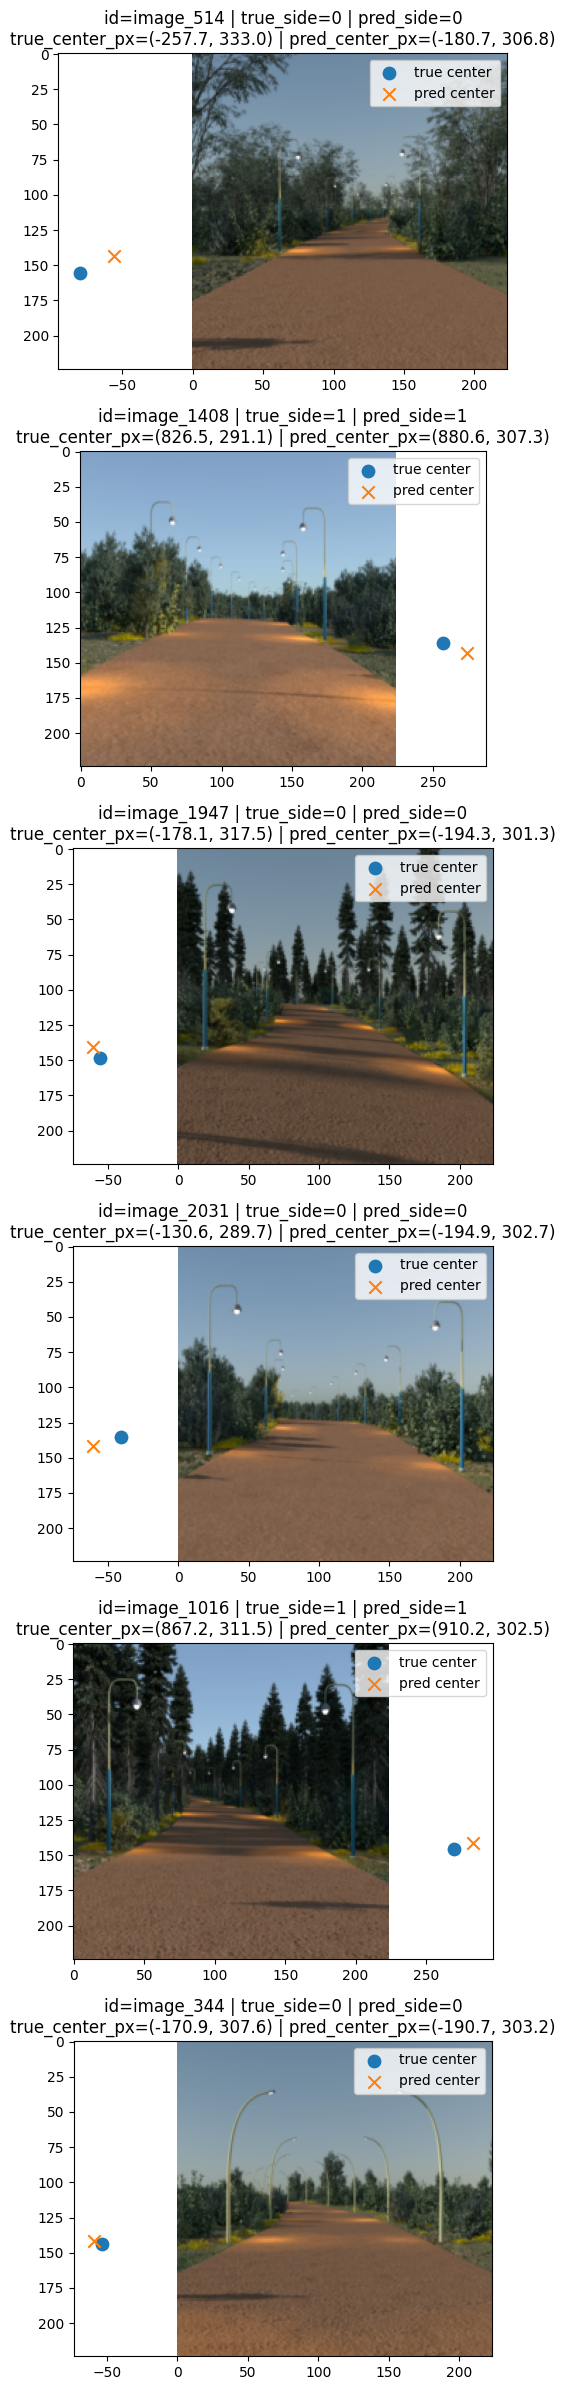

In [26]:
show_predictions(model, val_dataset, device, num_samples=6)